# 05 — Train GaitTR Fixed Recommended Version

This is the cleaned and fixed training notebook for your CASIA-B GaitTR experiment.

Default project path:

```python
/media/wadud/DriveUbuntu/GaitRecognition 2.0
```

This notebook expects:

```text
data/splits/train_LT.csv
data/poses/<pose_model_tag>/**/*.npz
```

Recommended defaults for your RTX 3060 Laptop 6GB:

```python
P = 8
K = 4
BATCH_SIZE = 32
USE_AMP = True
MAX_STEPS = 30000
```

Run order:

1. Run all setup/model/data cells.
2. Run tiny overfit test first.
3. If tiny loss decreases, set `RUN_FULL_TRAINING = True`.
4. Run full training.

In [1]:
# ============================================================
# CELL 1 — Imports, config, paths
# ============================================================

from pathlib import Path
import random
import time
import json
import gc

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader, Sampler
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

EXP_DIR = Path("/media/wadud/DriveUbuntu/GaitRecognition 2.0")
SPLIT_NAME = "LT"

SPLIT_DIR = EXP_DIR / "data" / "splits"
CHECKPOINT_DIR = EXP_DIR / "checkpoints"
LOG_DIR = EXP_DIR / "logs"
RESULT_DIR = EXP_DIR / "results"

for d in [CHECKPOINT_DIR, LOG_DIR, RESULT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

TRAIN_CSV = SPLIT_DIR / f"train_{SPLIT_NAME}.csv"

SEQ_LEN = 60
NUM_JOINTS = 17
IN_CHANNELS = 10
EMBEDDING_DIM = 128

CHANNELS = (64, 64, 128, 256)
NUM_HEADS = 8
TEMPORAL_KERNEL = 9
DROPOUT = 0.1

# Recommended for RTX 3060 6GB
P = 8
K = 4
BATCH_SIZE = P * K
NUM_WORKERS = 2

MAX_STEPS = 30000
STEPS_PER_EPOCH = 1000

MARGIN = 0.3
LR_MAX = 1e-3
WEIGHT_DECAY = 2e-5

USE_AMP = True
GRAD_CLIP_NORM = 5.0

LOG_EVERY = 50
SAVE_EVERY = 1000

# First keep tiny test ON, full training OFF.
RUN_TINY_OVERFIT_TEST = False
RUN_FULL_TRAINING = True

TINY_SUBJECTS = 5
TINY_STEPS = 500

# Resume full training if needed.
RESUME_FROM = None
# Example:
# RESUME_FROM = "/media/wadud/DriveUbuntu/GaitRecognition 2.0/checkpoints/gaittr_LT_fixed_step_5000.pth"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 80)
print("GaitTR Fixed Training Notebook")
print("=" * 80)
print("EXP_DIR     :", EXP_DIR)
print("TRAIN_CSV   :", TRAIN_CSV)
print("Device      :", device)
if torch.cuda.is_available():
    print("GPU         :", torch.cuda.get_device_name(0))
    print("CUDA        :", torch.version.cuda)
print("Batch config:", f"P={P}, K={K}, batch={BATCH_SIZE}")
print("=" * 80)

assert TRAIN_CSV.exists(), f"Missing {TRAIN_CSV}. Run 03_prepare_casiab_splits.ipynb first."

GaitTR Fixed Training Notebook
EXP_DIR     : /media/wadud/DriveUbuntu/GaitRecognition 2.0
TRAIN_CSV   : /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/splits/train_LT.csv
Device      : cuda
GPU         : NVIDIA GeForce RTX 3060 Laptop GPU
CUDA        : 12.8
Batch config: P=8, K=4, batch=32


In [2]:
# ============================================================
# CELL 2 — Read train split safely, preserving subject IDs
# ============================================================

df_train_full = pd.read_csv(
    TRAIN_CSV,
    dtype={
        "pose_path": str,
        "subject": str,
        "condition": str,
        "seq": str,
        "view": str,
    }
)

required_cols = {"pose_path", "subject", "condition", "seq", "view"}
missing_cols = required_cols - set(df_train_full.columns)
assert not missing_cols, f"Missing columns in train CSV: {missing_cols}"

missing_paths = [p for p in df_train_full["pose_path"].tolist() if not Path(p).exists()]

print("Train samples :", len(df_train_full))
print("Train subjects:", df_train_full["subject"].nunique())
print("Missing pose paths:", len(missing_paths))

if missing_paths:
    print("First missing path:", missing_paths[0])
    raise FileNotFoundError("Some pose paths in train CSV do not exist.")

display(df_train_full.head())
display(df_train_full.groupby(["condition", "seq"]).size().reset_index(name="count"))

Train samples : 8140
Train subjects: 74
Missing pose paths: 0


,pose_path,subject,condition,seq,view
0,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,001,bg,01,000
1,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,001,bg,01,018
2,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,001,bg,01,036
3,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,001,bg,01,054
4,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,001,bg,01,072


,condition,seq,count
0,bg,01,814
1,bg,02,814
2,cl,01,814
3,cl,02,814
4,nm,01,814
5,nm,02,814
6,nm,03,814
7,nm,04,814
8,nm,05,814
9,nm,06,814


In [3]:
# ============================================================
# CELL 3 — Feature builder and augmentations
# ============================================================

COCO_PARENTS = np.array([
    0,   # 0 nose
    0,   # 1 left_eye      <- nose
    0,   # 2 right_eye     <- nose
    1,   # 3 left_ear      <- left_eye
    2,   # 4 right_ear     <- right_eye
    0,   # 5 left_shoulder <- nose
    0,   # 6 right_shoulder<- nose
    5,   # 7 left_elbow    <- left_shoulder
    6,   # 8 right_elbow   <- right_shoulder
    7,   # 9 left_wrist    <- left_elbow
    8,   # 10 right_wrist  <- right_elbow
    5,   # 11 left_hip     <- left_shoulder
    6,   # 12 right_hip    <- right_shoulder
    11,  # 13 left_knee    <- left_hip
    12,  # 14 right_knee   <- right_hip
    13,  # 15 left_ankle   <- left_knee
    14,  # 16 right_ankle  <- right_knee
], dtype=np.int64)

LEFT_RIGHT_PAIRS = [
    (1, 2),
    (3, 4),
    (5, 6),
    (7, 8),
    (9, 10),
    (11, 12),
    (13, 14),
    (15, 16),
]

def crop_or_pad_sequence(X, seq_len=60, random_crop=True):
    T = X.shape[0]

    if T == seq_len:
        return X

    if T > seq_len:
        if random_crop:
            start = np.random.randint(0, T - seq_len + 1)
        else:
            start = max(0, (T - seq_len) // 2)
        return X[start:start + seq_len]

    pad_len = seq_len - T
    pad = np.repeat(X[-1:], pad_len, axis=0)
    return np.concatenate([X, pad], axis=0)

def swap_left_right(X):
    X = X.copy()
    for l, r in LEFT_RIGHT_PAIRS:
        X[:, [l, r], :] = X[:, [r, l], :]
    return X

def augment_skeleton(X):
    if np.random.rand() < 0.5:
        X = swap_left_right(X)

    X = X + np.random.normal(0.0, 0.005, size=X.shape).astype(np.float32)
    X = X + np.random.normal(0.0, 0.01, size=(1, 1, 2)).astype(np.float32)

    return X.astype(np.float32)

def build_gaittr_features(X):
    X = X.astype(np.float32)

    assert X.ndim == 3, f"Expected (T,17,2), got {X.shape}"
    assert X.shape[1] == 17, f"Expected 17 joints, got {X.shape[1]}"
    assert X.shape[2] == 2, f"Expected x,y coordinates, got {X.shape[2]}"

    joint = X.copy()

    nose = X[:, 0:1, :]
    joint_rel = X - nose

    v1 = np.zeros_like(X)
    v1[:-1] = X[1:] - X[:-1]

    v2 = np.zeros_like(X)
    v2[:-2] = X[2:] - X[:-2]

    bone = X - X[:, COCO_PARENTS, :]

    feat = np.concatenate([joint, joint_rel, v1, v2, bone], axis=-1)
    feat = feat.transpose(2, 0, 1).astype(np.float32)

    return feat

# Sanity check
test_path = df_train_full.iloc[0]["pose_path"]
test_data = np.load(test_path)
test_X = test_data["keypoints_norm_filled"].astype(np.float32)
test_X60 = crop_or_pad_sequence(test_X, SEQ_LEN, random_crop=False)
test_feat = build_gaittr_features(test_X60)

print("Test skeleton:", test_X.shape)
print("Test feature :", test_feat.shape)
assert test_feat.shape == (10, 60, 17)
print("[OK] Feature builder")

Test skeleton: (99, 17, 2)
Test feature : (10, 60, 17)
[OK] Feature builder


In [4]:
# ============================================================
# CELL 4 — Dataset and PK sampler
# ============================================================

class CASIABGaitTRDataset(Dataset):
    def __init__(self, df, label_map, seq_len=60, train=True, augment=True):
        self.df = df.reset_index(drop=True)
        self.label_map = label_map
        self.seq_len = seq_len
        self.train = train
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        data = np.load(row["pose_path"])
        X = data["keypoints_norm_filled"].astype(np.float32)

        X = crop_or_pad_sequence(
            X,
            seq_len=self.seq_len,
            random_crop=self.train
        )

        if self.train and self.augment:
            X = augment_skeleton(X)

        feat = build_gaittr_features(X)
        label = self.label_map[str(row["subject"])]

        return {
            "x": torch.from_numpy(feat),
            "label": torch.tensor(label, dtype=torch.long),
            "subject": str(row["subject"]),
            "condition": str(row["condition"]),
            "seq": str(row["seq"]),
            "view": str(row["view"]),
            "pose_path": str(row["pose_path"]),
        }


class PKBatchSampler(Sampler):
    def __init__(self, labels, p=8, k=4, steps_per_epoch=1000):
        self.labels = np.asarray(labels)
        self.p = int(p)
        self.k = int(k)
        self.steps_per_epoch = int(steps_per_epoch)

        self.label_to_indices = {}
        for idx, label in enumerate(self.labels):
            self.label_to_indices.setdefault(int(label), []).append(idx)

        self.unique_labels = sorted(self.label_to_indices.keys())

        if len(self.unique_labels) < self.p:
            raise ValueError(f"Not enough identities: have {len(self.unique_labels)}, need p={self.p}")

    def __iter__(self):
        for _ in range(self.steps_per_epoch):
            selected_labels = random.sample(self.unique_labels, self.p)

            batch_indices = []
            for label in selected_labels:
                indices = self.label_to_indices[label]
                if len(indices) >= self.k:
                    chosen = random.sample(indices, self.k)
                else:
                    chosen = random.choices(indices, k=self.k)
                batch_indices.extend(chosen)

            yield batch_indices

    def __len__(self):
        return self.steps_per_epoch


def make_label_map(df):
    subjects = sorted([str(s) for s in df["subject"].unique()])
    return {s: i for i, s in enumerate(subjects)}

def make_train_loader(df_train, p=P, k=K, steps_per_epoch=STEPS_PER_EPOCH, augment=True):
    label_map = make_label_map(df_train)

    dataset = CASIABGaitTRDataset(
        df=df_train,
        label_map=label_map,
        seq_len=SEQ_LEN,
        train=True,
        augment=augment,
    )

    labels = [label_map[str(s)] for s in df_train["subject"].tolist()]

    sampler = PKBatchSampler(
        labels=labels,
        p=p,
        k=k,
        steps_per_epoch=steps_per_epoch,
    )

    loader = DataLoader(
        dataset,
        batch_sampler=sampler,
        num_workers=NUM_WORKERS,
        pin_memory=(device.type == "cuda"),
        persistent_workers=(NUM_WORKERS > 0),
    )

    return loader, label_map

loader_check, label_map_check = make_train_loader(df_train_full, p=P, k=K, steps_per_epoch=5)
batch = next(iter(loader_check))

print("Batch x shape:", batch["x"].shape)
print("Batch y shape:", batch["label"].shape)
print("Unique IDs    :", torch.unique(batch["label"]).numel())

assert batch["x"].shape == (P*K, 10, 60, 17)
assert torch.unique(batch["label"]).numel() == P
print("[OK] Dataset and PK sampler")

Batch x shape: torch.Size([32, 10, 60, 17])
Batch y shape: torch.Size([32])
Unique IDs    : 8
[OK] Dataset and PK sampler


In [5]:
# ============================================================
# CELL 5 — GaitTR model and loss
# ============================================================

class TCN(nn.Module):
    def __init__(self, in_channels, out_channels, temporal_kernel=9, dropout=0.1):
        super().__init__()
        pad = temporal_kernel // 2

        self.net = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=(temporal_kernel, 1),
                padding=(pad, 0),
                bias=False
            ),
            nn.Dropout(dropout),
            nn.Mish(),
            nn.BatchNorm2d(out_channels),
        )

    def forward(self, x):
        return self.net(x)


class SpatialTransformer(nn.Module):
    def __init__(self, channels, num_heads=8, dropout=0.1):
        super().__init__()

        assert channels % num_heads == 0, (
            f"channels={channels} must be divisible by num_heads={num_heads}"
        )

        self.norm = nn.LayerNorm(channels)

        self.attn = nn.MultiheadAttention(
            embed_dim=channels,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True,
        )

        self.proj = nn.Linear(channels, channels)
        self.act = nn.Mish()
        self.bn = nn.BatchNorm2d(channels)

    def forward(self, x):
        # x: B x C x T x V
        B, C, T, V = x.shape

        # B x C x T x V -> B x T x V x C -> (B*T) x V x C
        tokens = x.permute(0, 2, 3, 1).contiguous()
        tokens = tokens.view(B * T, V, C)

        tokens = self.norm(tokens)
        out, _ = self.attn(tokens, tokens, tokens, need_weights=False)
        out = self.proj(out)

        # (B*T) x V x C -> B x C x T x V
        out = out.view(B, T, V, C)
        out = out.permute(0, 3, 1, 2).contiguous()

        out = self.act(out)
        out = self.bn(out)

        return out


class TCNSTBlock(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        num_heads=8,
        temporal_kernel=9,
        dropout=0.1,
    ):
        super().__init__()

        self.tcn = TCN(
            in_channels=in_channels,
            out_channels=out_channels,
            temporal_kernel=temporal_kernel,
            dropout=dropout,
        )

        self.st = SpatialTransformer(
            channels=out_channels,
            num_heads=num_heads,
            dropout=dropout,
        )

        if in_channels == out_channels:
            self.residual = nn.Identity()
        else:
            self.residual = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
                nn.Mish(),
                nn.BatchNorm2d(out_channels),
            )

    def forward(self, x):
        identity = self.residual(x)
        out = self.tcn(x)
        out = self.st(out)
        return out + identity


class GaitTR(nn.Module):
    def __init__(
        self,
        in_channels=10,
        embedding_dim=128,
        channels=(64, 64, 128, 256),
        num_heads=8,
        temporal_kernel=9,
        dropout=0.1,
    ):
        super().__init__()

        self.data_bn = nn.BatchNorm2d(in_channels)

        blocks = []
        prev_channels = in_channels

        for out_channels in channels:
            blocks.append(
                TCNSTBlock(
                    in_channels=prev_channels,
                    out_channels=out_channels,
                    num_heads=num_heads,
                    temporal_kernel=temporal_kernel,
                    dropout=dropout,
                )
            )
            prev_channels = out_channels

        self.blocks = nn.Sequential(*blocks)
        self.fc = nn.Linear(channels[-1], embedding_dim, bias=False)

    def forward(self, x):
        # x: B x 10 x 60 x 17
        x = self.data_bn(x)
        x = self.blocks(x)

        # Average over time and joints
        x = x.mean(dim=(2, 3))

        emb = self.fc(x)
        emb = F.normalize(emb, p=2, dim=1)

        return emb


class BatchHardTripletLoss(nn.Module):
    def __init__(self, margin=0.3):
        super().__init__()
        self.margin = margin

    def forward(self, embeddings, labels):
        dist = torch.cdist(embeddings, embeddings, p=2)

        labels = labels.view(-1, 1)
        same = labels.eq(labels.t())
        diff = ~same

        eye = torch.eye(labels.size(0), device=labels.device, dtype=torch.bool)
        same = same & ~eye

        hardest_pos = dist.masked_fill(~same, -1e9).max(dim=1)[0]
        hardest_neg = dist.masked_fill(~diff, 1e9).min(dim=1)[0]

        loss = F.relu(hardest_pos - hardest_neg + self.margin)
        valid = hardest_pos > -1e8

        if valid.sum() == 0:
            return torch.tensor(0.0, device=embeddings.device, requires_grad=True)

        return loss[valid].mean()


model_check = GaitTR(
    in_channels=IN_CHANNELS,
    embedding_dim=EMBEDDING_DIM,
    channels=CHANNELS,
    num_heads=NUM_HEADS,
    temporal_kernel=TEMPORAL_KERNEL,
    dropout=DROPOUT,
)

dummy = torch.randn(2, 10, 60, 17)
with torch.no_grad():
    out = model_check(dummy)

print("Output shape:", out.shape)
assert out.shape == (2, EMBEDDING_DIM)
print("[OK] Model forward")

del model_check, dummy, out
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Output shape: torch.Size([2, 128])
[OK] Model forward


In [6]:
# ============================================================
# CELL 6 — Training utilities
# ============================================================

def get_amp_scaler():
    if device.type != "cuda" or not USE_AMP:
        try:
            return torch.amp.GradScaler("cuda", enabled=False)
        except Exception:
            return torch.cuda.amp.GradScaler(enabled=False)

    try:
        return torch.amp.GradScaler("cuda", enabled=True)
    except Exception:
        return torch.cuda.amp.GradScaler(enabled=True)

def autocast_context():
    if device.type != "cuda" or not USE_AMP:
        try:
            return torch.amp.autocast("cuda", enabled=False)
        except Exception:
            return torch.cuda.amp.autocast(enabled=False)

    try:
        return torch.amp.autocast("cuda", enabled=True)
    except Exception:
        return torch.cuda.amp.autocast(enabled=True)

def save_checkpoint(path, model, optimizer, scheduler, scaler, step, config, label_map):
    ckpt = {
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict() if optimizer is not None else None,
        "scheduler": scheduler.state_dict() if scheduler is not None else None,
        "scaler": scaler.state_dict() if scaler is not None else None,
        "step": int(step),
        "config": config,
        "label_map": label_map,
    }
    torch.save(ckpt, path)

def load_checkpoint(path, model, optimizer=None, scheduler=None, scaler=None):
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt["model"], strict=True)

    if optimizer is not None and ckpt.get("optimizer") is not None:
        optimizer.load_state_dict(ckpt["optimizer"])

    if scheduler is not None and ckpt.get("scheduler") is not None:
        scheduler.load_state_dict(ckpt["scheduler"])

    if scaler is not None and ckpt.get("scaler") is not None:
        scaler.load_state_dict(ckpt["scaler"])

    return ckpt

def make_model():
    return GaitTR(
        in_channels=IN_CHANNELS,
        embedding_dim=EMBEDDING_DIM,
        channels=CHANNELS,
        num_heads=NUM_HEADS,
        temporal_kernel=TEMPORAL_KERNEL,
        dropout=DROPOUT,
    ).to(device)

def make_optimizer(model):
    return torch.optim.Adam(
        model.parameters(),
        lr=LR_MAX,
        weight_decay=WEIGHT_DECAY,
    )

def make_scheduler(optimizer, total_steps):
    return torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=LR_MAX,
        total_steps=total_steps,
        pct_start=0.3,
        div_factor=100.0,
        final_div_factor=100000.0,
    )

def get_config_dict(run_name, max_steps, p, k):
    return {
        "run_name": run_name,
        "split_name": SPLIT_NAME,
        "seq_len": SEQ_LEN,
        "in_channels": IN_CHANNELS,
        "embedding_dim": EMBEDDING_DIM,
        "channels": list(CHANNELS),
        "num_heads": NUM_HEADS,
        "temporal_kernel": TEMPORAL_KERNEL,
        "dropout": DROPOUT,
        "p": p,
        "k": k,
        "batch_size": p * k,
        "max_steps": max_steps,
        "margin": MARGIN,
        "lr_max": LR_MAX,
        "weight_decay": WEIGHT_DECAY,
        "use_amp": USE_AMP,
        "grad_clip_norm": GRAD_CLIP_NORM,
        "seed": SEED,
    }

In [7]:
# ============================================================
# CELL 7 — Training function
# ============================================================

def run_training(
    df_train,
    run_name,
    max_steps,
    p,
    k,
    steps_per_epoch,
    resume_from=None,
):
    train_loader, label_map = make_train_loader(
        df_train,
        p=p,
        k=k,
        steps_per_epoch=steps_per_epoch,
        augment=True,
    )

    model = make_model()
    criterion = BatchHardTripletLoss(margin=MARGIN)
    optimizer = make_optimizer(model)
    scheduler = make_scheduler(optimizer, total_steps=max_steps)
    scaler = get_amp_scaler()

    start_step = 0
    config = get_config_dict(run_name, max_steps, p, k)

    if resume_from is not None:
        resume_from = Path(resume_from)
        assert resume_from.exists(), f"Checkpoint not found: {resume_from}"
        ckpt = load_checkpoint(resume_from, model, optimizer, scheduler, scaler)
        start_step = int(ckpt.get("step", 0))
        print(f"[RESUME] Loaded {resume_from}, start_step={start_step}")

    logs = []
    best_loss = float("inf")
    best_path = CHECKPOINT_DIR / f"{run_name}_best_loss.pth"
    last_path = CHECKPOINT_DIR / f"{run_name}_last.pth"

    model.train()
    step = start_step
    start_time = time.time()

    pbar = tqdm(total=max_steps, initial=start_step, desc=run_name)

    while step < max_steps:
        for batch in train_loader:
            x = batch["x"].float().to(device, non_blocking=True)
            y = batch["label"].long().to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with autocast_context():
                emb = model(x)
                loss = criterion(emb, y)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)

            if GRAD_CLIP_NORM is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)

            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            loss_value = float(loss.detach().cpu())
            lr = float(scheduler.get_last_lr()[0])
            elapsed = time.time() - start_time

            if step % LOG_EVERY == 0:
                log_row = {
                    "step": step,
                    "loss": loss_value,
                    "lr": lr,
                    "elapsed_sec": elapsed,
                    "batch_size": p * k,
                    "p": p,
                    "k": k,
                }
                logs.append(log_row)
                pbar.set_postfix({"loss": f"{loss_value:.4f}", "lr": f"{lr:.2e}"})

                if loss_value < best_loss:
                    best_loss = loss_value
                    save_checkpoint(
                        best_path,
                        model, optimizer, scheduler, scaler, step, config, label_map
                    )

            if step > 0 and step % SAVE_EVERY == 0:
                step_path = CHECKPOINT_DIR / f"{run_name}_step_{step}.pth"
                save_checkpoint(
                    step_path,
                    model, optimizer, scheduler, scaler, step, config, label_map
                )

            step += 1
            pbar.update(1)

            if step >= max_steps:
                break

    pbar.close()

    save_checkpoint(
        last_path,
        model, optimizer, scheduler, scaler, step, config, label_map
    )

    df_log = pd.DataFrame(logs)
    log_csv = LOG_DIR / f"{run_name}_train_log.csv"
    df_log.to_csv(log_csv, index=False)

    config_json = LOG_DIR / f"{run_name}_config.json"
    with open(config_json, "w") as f:
        json.dump(config, f, indent=2)

    if len(df_log) > 0:
        plt.figure(figsize=(9, 4))
        plt.plot(df_log["step"], df_log["loss"])
        plt.xlabel("Step")
        plt.ylabel("Batch-hard triplet loss")
        plt.title(run_name)
        plt.grid(True, alpha=0.3)
        plot_path = LOG_DIR / f"{run_name}_loss_curve.png"
        plt.tight_layout()
        plt.savefig(plot_path, dpi=150)
        plt.show()
    else:
        plot_path = None

    print("=" * 80)
    print("Training finished:", run_name)
    print("Last checkpoint :", last_path)
    print("Best checkpoint :", best_path)
    print("Log CSV         :", log_csv)
    print("Config JSON     :", config_json)
    if plot_path:
        print("Loss plot       :", plot_path)
    print("=" * 80)

    return model, df_log, label_map

In [8]:
# ============================================================
# CELL 8 — Tiny overfit test
# ============================================================

if RUN_TINY_OVERFIT_TEST:
    tiny_subjects = sorted(df_train_full["subject"].unique())[:TINY_SUBJECTS]
    df_tiny = df_train_full[df_train_full["subject"].isin(tiny_subjects)].copy()

    tiny_p = min(P, TINY_SUBJECTS)

    print("=" * 80)
    print("Tiny overfit test")
    print("=" * 80)
    print("Tiny subjects:", tiny_subjects)
    print("Tiny samples :", len(df_tiny))
    print("P, K         :", tiny_p, K)
    print("Steps        :", TINY_STEPS)
    print("=" * 80)

    tiny_model, tiny_log, tiny_label_map = run_training(
        df_train=df_tiny,
        run_name=f"gaittr_{SPLIT_NAME}_tiny_overfit_fixed",
        max_steps=TINY_STEPS,
        p=tiny_p,
        k=K,
        steps_per_epoch=100,
        resume_from=None,
    )

    if len(tiny_log) > 1:
        first_loss = float(tiny_log["loss"].iloc[0])
        last_loss = float(tiny_log["loss"].iloc[-1])
        min_loss = float(tiny_log["loss"].min())

        print("First loss:", first_loss)
        print("Last loss :", last_loss)
        print("Min loss  :", min_loss)

        if last_loss < first_loss:
            print("[OK] Tiny overfit loss decreased. Full training is safe to start.")
        else:
            print("[WARNING] Tiny loss did not decrease. Inspect data/model before full training.")

else:
    print("RUN_TINY_OVERFIT_TEST=False")

RUN_TINY_OVERFIT_TEST=False


gaittr_LT_fixed:   0%|          | 0/30000 [00:00<?, ?it/s]

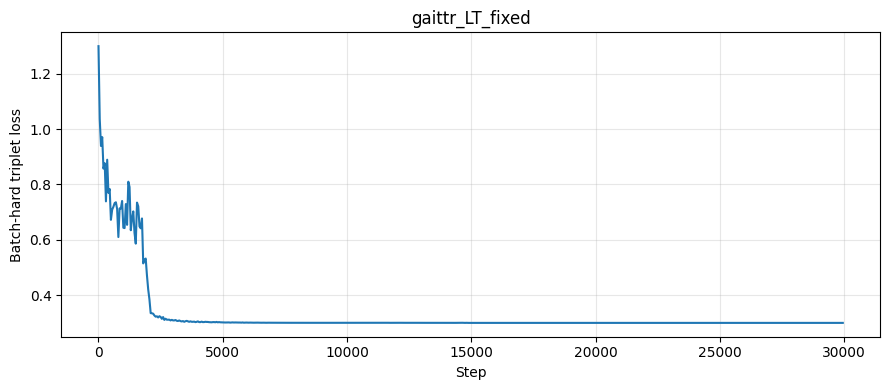

Training finished: gaittr_LT_fixed
Last checkpoint : /media/wadud/DriveUbuntu/GaitRecognition 2.0/checkpoints/gaittr_LT_fixed_last.pth
Best checkpoint : /media/wadud/DriveUbuntu/GaitRecognition 2.0/checkpoints/gaittr_LT_fixed_best_loss.pth
Log CSV         : /media/wadud/DriveUbuntu/GaitRecognition 2.0/logs/gaittr_LT_fixed_train_log.csv
Config JSON     : /media/wadud/DriveUbuntu/GaitRecognition 2.0/logs/gaittr_LT_fixed_config.json
Loss plot       : /media/wadud/DriveUbuntu/GaitRecognition 2.0/logs/gaittr_LT_fixed_loss_curve.png


In [9]:
# ============================================================
# CELL 9 — Full training
# ============================================================

if RUN_FULL_TRAINING:
    full_model, full_log, full_label_map = run_training(
        df_train=df_train_full,
        run_name=f"gaittr_{SPLIT_NAME}_fixed",
        max_steps=MAX_STEPS,
        p=P,
        k=K,
        steps_per_epoch=STEPS_PER_EPOCH,
        resume_from=RESUME_FROM,
    )
else:
    print("RUN_FULL_TRAINING=False")
    print("After tiny overfit test passes, set:")
    print("RUN_TINY_OVERFIT_TEST = False")
    print("RUN_FULL_TRAINING = True")
    print("Then rerun this notebook/cell.")

Training log files:
- gaittr_LT_fixed_train_log.csv
- gaittr_LT_tiny_overfit_train_log.csv
Latest log: /media/wadud/DriveUbuntu/GaitRecognition 2.0/logs/gaittr_LT_tiny_overfit_train_log.csv


,step,loss,lr,elapsed_sec
0,0,1.161013,0.000010,0.897964
1,50,1.051318,0.000270,3.942985
2,100,0.821556,0.000767,6.861188
3,150,0.823077,0.001000,9.785349
4,200,1.067306,0.000947,12.729712


,step,loss,lr,elapsed_sec
5,250,0.704451,0.000805,15.409973
6,300,0.297794,0.000602,17.911011
7,350,0.269789,0.000380,20.418260
8,400,0.271646,0.000181,22.977467
9,450,0.262488,0.000046,25.524689


First loss: 1.1610130071640017
Last loss : 0.2624876499176025
Min loss  : 0.2624876499176025


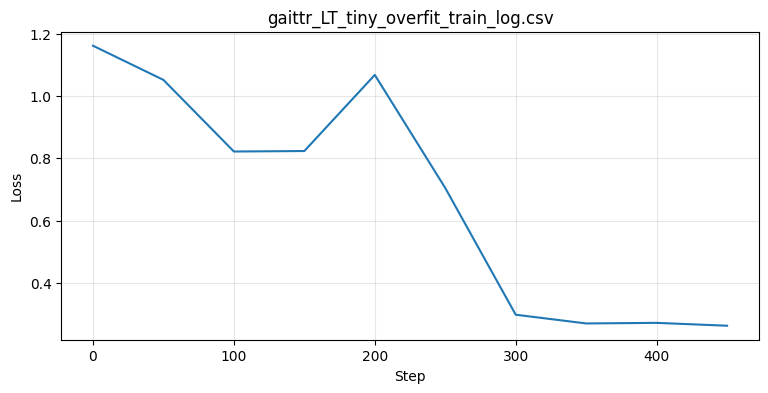

In [10]:
# ============================================================
# CELL 10 — Inspect latest training logs
# ============================================================

log_files = sorted(LOG_DIR.glob("gaittr_*_train_log.csv"))

print("Training log files:")
for p in log_files:
    print("-", p.name)

if log_files:
    latest_log = log_files[-1]
    df_log_latest = pd.read_csv(latest_log)

    print("Latest log:", latest_log)
    display(df_log_latest.head())
    display(df_log_latest.tail())

    if len(df_log_latest) > 0:
        print("First loss:", df_log_latest["loss"].iloc[0])
        print("Last loss :", df_log_latest["loss"].iloc[-1])
        print("Min loss  :", df_log_latest["loss"].min())

        plt.figure(figsize=(9, 4))
        plt.plot(df_log_latest["step"], df_log_latest["loss"])
        plt.xlabel("Step")
        plt.ylabel("Loss")
        plt.title(latest_log.name)
        plt.grid(True, alpha=0.3)
        plt.show()

## Notes

Recommended workflow:

1. First run with:

```python
RUN_TINY_OVERFIT_TEST = True
RUN_FULL_TRAINING = False
```

2. If tiny loss decreases, change to:

```python
RUN_TINY_OVERFIT_TEST = False
RUN_FULL_TRAINING = True
```

3. After full training, use:

```text
checkpoints/gaittr_LT_fixed_last.pth
```

or:

```text
checkpoints/gaittr_LT_fixed_best_loss.pth
```

Then run the evaluation notebook.

In [11]:
from pathlib import Path
import pandas as pd

EXP_DIR = Path("/media/wadud/DriveUbuntu/GaitRecognition 2.0")

CHECKPOINT_DIR = EXP_DIR / "checkpoints"
LOG_DIR = EXP_DIR / "logs"

print("Checkpoints:")
for p in sorted(CHECKPOINT_DIR.glob("gaittr_LT_fixed*.pth")):
    print(p.name)

print("\nLogs:")
for p in sorted(LOG_DIR.glob("gaittr_LT_fixed*.csv")):
    print(p.name)

Checkpoints:
gaittr_LT_fixed_best_loss.pth
gaittr_LT_fixed_last.pth
gaittr_LT_fixed_step_1000.pth
gaittr_LT_fixed_step_10000.pth
gaittr_LT_fixed_step_11000.pth
gaittr_LT_fixed_step_12000.pth
gaittr_LT_fixed_step_13000.pth
gaittr_LT_fixed_step_14000.pth
gaittr_LT_fixed_step_15000.pth
gaittr_LT_fixed_step_16000.pth
gaittr_LT_fixed_step_17000.pth
gaittr_LT_fixed_step_18000.pth
gaittr_LT_fixed_step_19000.pth
gaittr_LT_fixed_step_2000.pth
gaittr_LT_fixed_step_20000.pth
gaittr_LT_fixed_step_21000.pth
gaittr_LT_fixed_step_22000.pth
gaittr_LT_fixed_step_23000.pth
gaittr_LT_fixed_step_24000.pth
gaittr_LT_fixed_step_25000.pth
gaittr_LT_fixed_step_26000.pth
gaittr_LT_fixed_step_27000.pth
gaittr_LT_fixed_step_28000.pth
gaittr_LT_fixed_step_29000.pth
gaittr_LT_fixed_step_3000.pth
gaittr_LT_fixed_step_4000.pth
gaittr_LT_fixed_step_5000.pth
gaittr_LT_fixed_step_6000.pth
gaittr_LT_fixed_step_7000.pth
gaittr_LT_fixed_step_8000.pth
gaittr_LT_fixed_step_9000.pth

Logs:
gaittr_LT_fixed_train_log.csv


,step,loss,lr,elapsed_sec,batch_size,p,k
0,0,1.299637,0.000010,0.817820,32,8,4
1,50,1.036375,0.000010,5.604242,32,8,4
2,100,0.939232,0.000010,10.318354,32,8,4
3,150,0.971023,0.000011,14.991700,32,8,4
4,200,0.857415,0.000011,19.735969,32,8,4


,step,loss,lr,elapsed_sec,batch_size,p,k
595,29750,0.3,3.441762e-07,2543.746672,32,8,4
596,29800,0.3,2.194309e-07,2547.888874,32,8,4
597,29850,0.3,1.226482e-07,2551.969797,32,8,4
598,29900,0.3,5.383355e-08,2556.105328,32,8,4
599,29950,0.3,1.299086e-08,2560.213935,32,8,4


First loss: 1.2996373176574707
Last loss : 0.3000000119209289
Min loss  : 0.3000000119209289


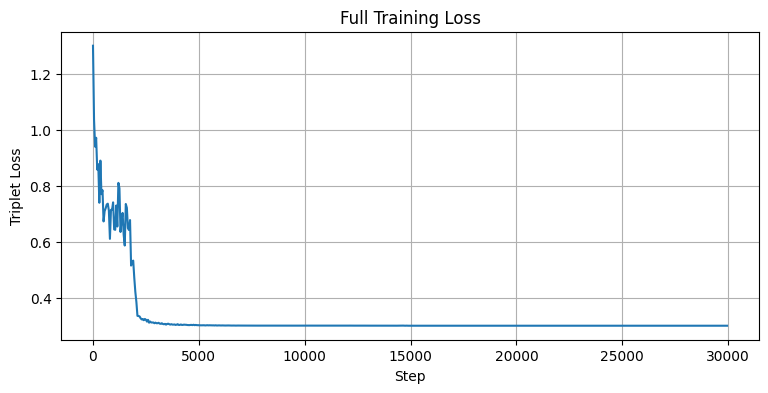

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

EXP_DIR = Path("/media/wadud/DriveUbuntu/GaitRecognition 2.0")
log_path = EXP_DIR / "logs" / "gaittr_LT_fixed_train_log.csv"

df_log = pd.read_csv(log_path)

display(df_log.head())
display(df_log.tail())

print("First loss:", df_log["loss"].iloc[0])
print("Last loss :", df_log["loss"].iloc[-1])
print("Min loss  :", df_log["loss"].min())

plt.figure(figsize=(9, 4))
plt.plot(df_log["step"], df_log["loss"])
plt.xlabel("Step")
plt.ylabel("Triplet Loss")
plt.title("Full Training Loss")
plt.grid(True)
plt.show()